In [ ]:
# Import
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

In [ ]:
# Dataset IMDB
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [ ]:
# Preprocessing
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

print("Shape of training data:", x_train.shape)
print("Shape of testing data:", x_test.shape)

Shape of training data: (25000, 200)
Shape of testing data: (25000, 200)


In [ ]:
model = Sequential()

# Embedding
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length))

# RNN (LSTM)
model.add(LSTM(64))

# Output
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 276ms/step - accuracy: 0.6973 - loss: 0.5421 - val_accuracy: 0.8432 - val_loss: 0.3708
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 278ms/step - accuracy: 0.8979 - loss: 0.2607 - val_accuracy: 0.8738 - val_loss: 0.3527
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 291ms/step - accuracy: 0.9349 - loss: 0.1763 - val_accuracy: 0.8618 - val_loss: 0.4038
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 276ms/step - accuracy: 0.9524 - loss: 0.1338 - val_accuracy: 0.8734 - val_loss: 0.3673
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 283ms/step - accuracy: 0.9685 - loss: 0.0932 - val_accuracy: 0.8686 - val_loss: 0.4364


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.8555 - loss: 0.4840
Test Loss: 0.4842584431171417
Test Accuracy: 0.8554400205612183


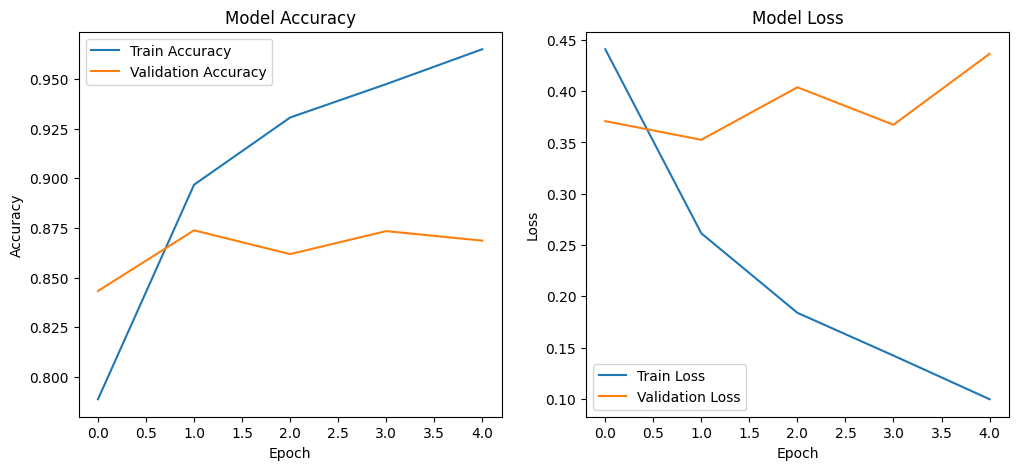

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
prediction = model.predict(x_test[0].reshape(1,200))

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
Prediction Score: [[0.01399169]]
Negative Review
